In [61]:
%load_ext autoreload
%autoreload 2

import torch
from torch import nn, Tensor
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
from torch.utils.data import Dataset, random_split
from torch.nn.utils.rnn import pad_sequence
import json
import random
import math
from torch.utils.tensorboard import SummaryWriter
import time
from utils.feature_engineering import get_delta_features, get_elapsed_feature
import numpy as np


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
from dataset.otto_trace import TraceOttoDataSet

#DataSet    
dataset_processed = TraceOttoDataSet(
    file_name='train.jsonl',
    input_seq_len=64,
    min_timestamps_per_sample=16,
    max_samples=200000
)

      
#See if the Lenght of the new inputs are the Lenght Sequence
for i,sample in enumerate(dataset_processed):
    len_sample = sample["inputs"]
    print(len(len_sample["timestamps"]))
    if i == 0:
        break    


print("================================================ (Logits part) ===================================================")
print("Logits Data_set_processed the ATC (Add to the Cart)")
print(dataset_processed.__ATC_task_logit__())
    
print("Logits for SAT4 (Seeing the same Aid 4 times)")
print(dataset_processed.__SAT__task_logit__())
    
print("Logits for PD1 (Make any Purchase within a day)")
print(dataset_processed.__PD1_task_logit___())
    
print("Logits for RA1 (Return to the same Aid in 1 days)")
print(dataset_processed.__RA1_task_logit___())

64
================================================ (Logits part) ===================================================
Logits Data_set_processed the ATC (Add to the Cart)
[1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0

In [64]:
# Data splitting train/test

# Jan: Splitting 98% train, 2% test - is this intended? And why? 2% of the data for test set is way too little.
#TRAINING_DATA_SET = 0.98
#TEST_SET = 0.02
train_portion = 0.80
train_data, test_data = random_split(dataset=dataset_processed, lengths=[train_portion, 1 - train_portion])


#DEV_SET
"""
validation_loader = DataLoader(
    dataset=val_data,
    batch_size=32,
    collate_fn=custom_collate,
    shuffle=False
)
"""

#TRAIN SET
train_loader = DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=True
)
#TEST SET
test_loader = DataLoader(
    dataset=test_data,
    batch_size=32,
    shuffle=False
)


5482386
87022


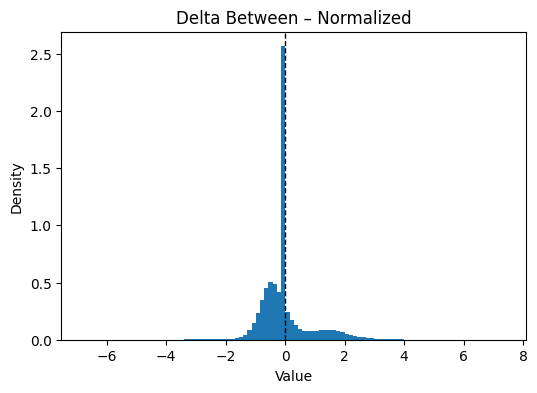

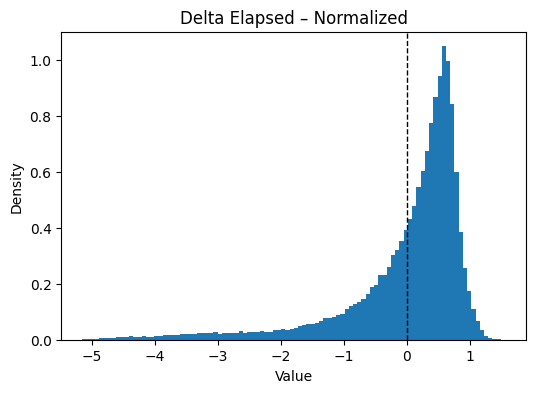

Delta Between:
 mean: -2.3153067e-10
 std : 0.82643104
 max |x|: 7.393063

Delta Elapsed:
 mean: 9.657621e-09
 std : 0.9842469
 max |x|: 5.153672


In [65]:
delta_elapsed_normalized = []
delta_between_normalized = []
for i, batch_trainer in enumerate(train_loader):
    evidence = batch_trainer["inputs"]
    timestamps = evidence["timestamps"]

    delta_elapsed_normalized.append(get_elapsed_feature(timestamps))
    delta_between_normalized.append(get_delta_features(timestamps))

    """ 
    print(f"[{i}] Delta BETWEEN")
    print("  mean:", delta_between_normalized.mean())
    print("  std :", delta_between_normalized.std())
    #print("  max |x|:", np.max(delta_between_normalized))

    
    print(f"[{i}] Delta ELAPSED")
    print("  mean:", delta_elapsed_normalized.mean())
    print("  std :", delta_elapsed_normalized.std())"""
    #print("  max |x|:", np.max(delta_elapsed_normalized))
    
    
import matplotlib.pyplot as plt
#mask = delta_between != 0
import torch

x = torch.cat([d.flatten() for d in delta_between_normalized]).cpu().numpy()
y = torch.cat([d.flatten() for d in delta_elapsed_normalized]).cpu().numpy()

print(len(x))

print(len(y))
plt.figure(figsize=(6,4))
plt.hist(x, bins=100, density=True)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Delta Between – Normalized")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(y , bins=100, density=True)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Delta Elapsed – Normalized")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()


print("Delta Between:")
print(" mean:", x.mean())
print(" std :", x.std())
print(" max |x|:", np.max(np.abs(x)))

print("\nDelta Elapsed:")
print(" mean:", y.mean())
print(" std :", y.std())
print(" max |x|:", np.max(np.abs(y)))

In [37]:
from model.trace import TRACE

max_aid = max(
    session["inputs"]["aid"].max().item()
    for session in dataset_processed
)
max_type = max(
    session["inputs"]["type"].max().item()
    for session in dataset_processed
)

num_embeddings_aid = max_aid + 1  
num_embeddings_event_type = max_type + 1
trace_model = TRACE(
    num_embeddings_aid=num_embeddings_aid,
    num_embeddings_event_type=num_embeddings_event_type,
    embedding_dim=32,
    num_classes=1 #4 # Jan: You are doing only one class here, so not 4 classes...
)

In [38]:
for batch_training in train_loader:
    sample = batch_training["inputs"]

    print(
        f"Shape Aids: {sample['aid'].shape}, "
        f"Shape Timestamps: {sample['timestamps'].shape}, "
        f"Shape Type: {sample['type'].shape}"
    )
    break  

Shape Aids: torch.Size([32, 64]), Shape Timestamps: torch.Size([32, 64]), Shape Type: torch.Size([32, 64])


In [ ]:
from utils.feature_engineering import get_delta_features, get_elapsed_feature

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(trace_model.parameters(), lr=1e-5, weight_decay=1e-6)

num_epochs = 15

#Summary Writer for tensorBoard
tensor_board_writer = SummaryWriter(log_dir=f"runs/exp_{time.time()}")


trace_model.train()

for epoch in range(num_epochs):
    epoch_loss = 0.0
    
    for batch_trainer in train_loader:
        evidence = batch_trainer["inputs"]
        
        # This is a bit suboptimal, but ok
        label_samplel = batch_trainer["targets"]
        label = label_samplel["ATC"].unsqueeze_(1)
        
        aids = evidence["aid"]
        events_type = evidence["type"]
        timestamps = evidence["timestamps"]      

        # Jan: Feature engineering here? This should be separate ... (see what I did)
        # Also, ideally you want to move this into the dataset class and precompute
        # No need to compute this within every iteration unless it dynamically changes (which I don't think it does, or am I wrong?)
        delta_elapsed_normalized = get_elapsed_feature(timestamps)
        delta_between_normalized = get_delta_features(timestamps)

        pred = trace_model(
            aids,
            events_type,
            delta_elapsed_normalized,
            delta_between_normalized
        )

        loss = criterion(pred, label.float())
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    train_loss = epoch_loss/len(train_loader)
    tensor_board_writer.add_scalar(f"Train_loss", epoch_loss/len(train_loader), epoch)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(train_loader):.4f}")
    
    """
    trace_model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_test in test_loader:
            
            batch_X_test = batch_test["inputs"]
            
            batch_Y_test = batch_test["targets"]
            
            batch_ATC_test = batch_Y_test["ATC"].unsqueeze_(1)

        
            aids_test = evidence["aid"]
            events_type_test = evidence["type"]
            timestamps_test = evidence["timestamps"]  
            
            delta_elapsed_normalized_test = get_elapsed_feature(timestamps_test)
            delta_between_normalized_test = get_delta_features(timestamps_test)
            
            pred_test = trace_model(
                aids_test, events_type_test, delta_elapsed_normalized_test, delta_between_normalized_test
            )
            loss_validation = criterion(pred_test.contiguous(), batch_ATC_test)

    
    val_loss /= len(test_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] Val Loss: {val_loss:.2f}")
"""


Epoch [1/15], Loss: 0.7015


ValueError: Target size (torch.Size([32, 1])) must be the same as input size (torch.Size([5, 1]))